<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [172]:
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';')
df.shape

(44744, 12)

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [173]:
df.head()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

4. Обратите внимание на информацию о числе непустых значений.

In [175]:
missing_values = df.isnull().sum()
columns_with_missing = missing_values[missing_values > 0]
print(columns_with_missing)

Опыт работы                        168
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
dtype: int64


5. Выведите основную статистическую информацию о столбцах.


In [176]:
unique_experience_count = df['Опыт работы'].drop_duplicates().count()
print(f"Количество уникальных значений в столбце 'Опыт работы': {unique_experience_count}")

Количество уникальных значений в столбце 'Опыт работы': 44413


In [177]:
most_common_position = df['Ищет работу на должность:'].mode()[0]
print(f"Самая распространенная искомая должность: {most_common_position}")

Самая распространенная искомая должность: Системный администратор


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [178]:
def extract_education_level(education_text):
    first_two_words = ' '.join(education_text.split()[:2]).lower()

    if 'высшее' in first_two_words and 'неоконченное' not in first_two_words:
        return 'высшее'
    elif 'неоконченное высшее' in first_two_words:
        return 'неоконченное высшее'
    elif 'среднее специальное' in first_two_words:
        return 'среднее специальное'
    elif 'среднее' in first_two_words:
        return 'среднее'
    else:
        return 'другое'

df['Образование'] = df['Образование и ВУЗ'].apply(extract_education_level)
df = df.drop('Образование и ВУЗ', axis=1)

print("Уникальные категории образования:")
print(df['Образование'].unique())

print("\nРаспределение по категориям образования:")
print(df['Образование'].value_counts())

Уникальные категории образования:
['неоконченное высшее' 'высшее' 'среднее специальное' 'среднее']

Распределение по категориям образования:
Образование
высшее                 33863
среднее специальное     5765
неоконченное высшее     4557
среднее                  559
Name: count, dtype: int64


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [179]:
def extract_gender(text):
    first_part = text.split(' , ')[0].strip()
    if first_part == 'Мужчина':
        return 'М'
    elif first_part == 'Женщина':
        return 'Ж'
    else:
        return None
    
def extract_age(text):
    parts = text.split(' , ')
    if len(parts) >= 2:
        age_part = parts[1].strip()
        age_number = ''.join(filter(str.isdigit, age_part))
        return int(age_number) if age_number else None
    return None

df['Пол'] = df['Пол, возраст'].apply(extract_gender)
df['Возраст'] = df['Пол, возраст'].apply(extract_age)
df = df.drop('Пол, возраст', axis=1)

Сколько процентов женских резюме представлено в наших данных? Ответ округлите до сотых.

In [180]:
gender_counts = df['Пол'].value_counts()
total_resumes = len(df)
female_count = gender_counts.get('Ж', 0)
female_percentage = (female_count / total_resumes) * 100
print(f"Процент женских резюме: {female_percentage:.2f}%")

Процент женских резюме: 19.07%


Чему равен средний возраст соискателей? Ответ округлите до десятых.

In [181]:
average_age = df['Возраст'].mean()
print(f"Средний возраст: {average_age:.1f}")

Средний возраст: 32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [182]:
def experience_to_months(experience_text):
    if pd.isna(experience_text) or experience_text == 'Не указано':
        return np.nan

    main_part = experience_text
    
    years = 0
    months = 0
    words = main_part.split()

    for i in range(len(words[:7])):
        if words[i] in ['год', 'года', 'лет']:
            try:
                years = int(words[i-1])
            except (ValueError, IndexError):
                continue
        elif words[i] in ['месяц', 'месяца', 'месяцев']:
            try:
                months = int(words[i-1])
            except (ValueError, IndexError):
                continue

    total_months = years * 12 + months
    return total_months


df['Опыт работы (месяц)'] = df['Опыт работы'].apply(experience_to_months)

In [183]:
df = df.drop('Опыт работы', axis=1)

In [184]:
print("Статистика по опыту работы в месяцах:")
print(df['Опыт работы (месяц)'].describe())

Статистика по опыту работы в месяцах:
count    44574.000000
mean       114.418944
std         79.047861
min          1.000000
25%         57.000000
50%        100.000000
75%        154.000000
max       1188.000000
Name: Опыт работы (месяц), dtype: float64


In [185]:
median_experience = df['Опыт работы (месяц)'].median()
print(f"Медианный опыт работы: {median_experience} месяцев")

Медианный опыт работы: 100.0 месяцев


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [186]:
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 
                 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 
                 'Воронеж', 'Волгоград']

In [187]:
def parse_city(text):
    first_part = text.split(' , ')[0].strip()

    if ' , м. ' in text:
        city_part = text.split(' , м. ')[0].strip()
    else:
        city_part = first_part

    if city_part == 'Москва':
        return 'Москва'
    elif city_part == 'Санкт-Петербург':
        return 'Санкт-Петербург'
    elif city_part in million_cities:
        return 'город-миллионник'
    else:
        return 'другие'

In [188]:
def parse_relocation(text):
    if pd.isna(text):
        return False
    
    text_lower = text.lower()

    if 'не готов к переезду' in text_lower or 'не готова к переезду' in text_lower:
        return False

    if 'готов к переезду' in text_lower or 'готова к переезду' in text_lower or \
       'хочу переехать' in text_lower or 'хотел бы переехать' in text_lower or \
       'хотела бы переехать' in text_lower:
        return True
    
    return False

def parse_business_trips(text):
    if pd.isna(text):
        return False
    
    text_lower = text.lower()

    if 'не готов к командировкам' in text_lower or 'не готова к командировкам' in text_lower:
        return False

    if 'готов к командировкам' in text_lower or 'готова к командировкам' in text_lower or \
       'готов к редким командировкам' in text_lower or 'готова к редким командировкам' in text_lower:
        return True

    return False

In [189]:
df['Город'] = df['Город, переезд, командировки'].apply(parse_city)
df['Готовность к переезду'] = df['Город, переезд, командировки'].apply(parse_relocation)
df['Готовность к командировкам'] = df['Город, переезд, командировки'].apply(parse_business_trips)


In [190]:
spb_percent = round(100 * (df['Город'] == 'Санкт-Петербург').sum() / len(df))
both_ready_percent = round(100 * ((df['Готовность к переезду']) & (df['Готовность к командировкам'])).sum() / len(df))

print(f"Процент соискателей из Санкт-Петербурга: {spb_percent}%")
print(f"Процент готовых к переездам И командировкам: {both_ready_percent}%")

Процент соискателей из Санкт-Петербурга: 11%
Процент готовых к переездам И командировкам: 32%


In [191]:
df = df.drop('Город, переезд, командировки', axis=1)

5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [192]:
occupations = ['полная занятость', 'частичная занятость', 'проектная работа', 
               'волонтерство', 'стажировка']

for occupation in occupations:
    df[occupation] = df['Занятость'].apply(
        lambda x: occupation in x.lower() if pd.notna(x) else False
    )

schedules = ['полный день', 'сменный график', 'гибкий график', 
             'удаленная работа', 'вахтовый метод']

for schedule in schedules:
    df[schedule] = df['График'].apply(
        lambda x: schedule in x.lower() if pd.notna(x) else False
    )

In [193]:
project_and_volunteer = ((df['проектная работа']) & (df['волонтерство'])).sum()
print(f"Проектная работа И волонтерство: {project_and_volunteer}")

shift_and_flexible = ((df['вахтовый метод']) & (df['гибкий график'])).sum()
print(f"Вахтовый метод И гибкий график: {shift_and_flexible}")

Проектная работа И волонтерство: 436
Вахтовый метод И гибкий график: 2311


In [194]:
df.drop(['Занятость', 'График'], axis=1, inplace=True)

6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [195]:
def get_salary_num(arg):
    salary =float(arg.split(' ')[0])
    return salary

def get_salary_currency(arg):
    currency_dict = {
        'USD': 'USD', 'KZT': 'KZT',
        'грн': 'UAH', 'белруб': 'BYN',
        'EUR': 'EUR', 'KGS': 'KGS',
        'сум': 'UZS', 'AZN': 'AZN'
    }
    curr = arg.split(' ')[1].replace('.', '')
    if curr == 'руб':
        return 'RUB'
    else:
        return currency_dict[curr]
    
rates = pd.read_csv('ExchangeRates.csv')
rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date
df['Обновление резюме'] = pd.to_datetime(df['Обновление резюме'], dayfirst=True).dt.date
df['ЗП (tmp)'] = df['ЗП'].apply(get_salary_num)
df['Курс (tmp)'] = df['ЗП'].apply(get_salary_currency)
merged = df.merge(
    rates, 
    left_on=['Курс (tmp)', 'Обновление резюме'],
    right_on=['currency', 'date',], 
    how='left'
)
merged['close'] = merged['close'].fillna(1)
merged['proportion'] = merged['proportion'].fillna(1)
df['ЗП (руб)'] = merged['close'] * merged['ЗП (tmp)'] / merged['proportion']
data = df.drop(['ЗП', 'ЗП (tmp)', 'Курс (tmp)'], axis=1)
print(round(data['ЗП (руб)'].median()/1000))

C:\Users\Kirill\AppData\Local\Temp\ipykernel_3496\1527341688.py:19: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



59


In [196]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последнее/нынешнее место работы  44743 non-null  object 
 2   Последняя/нынешняя должность     44742 non-null  object 
 3   Обновление резюме                44744 non-null  object 
 4   Авто                             44744 non-null  object 
 5   Образование                      44744 non-null  object 
 6   Пол                              44744 non-null  object 
 7   Возраст                          44744 non-null  int64  
 8   Опыт работы (месяц)              44574 non-null  float64
 9   Город                            44744 non-null  object 
 10  Готовность к переезду            44744 non-null  bool   
 11  Готовность к командировкам       44744 non-null  bool   
 12  полная занятость  

# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [197]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Распределение возраста', 'Box plot возраста'))

fig.add_trace(
    go.Histogram(x=data['Возраст'], nbinsx=50, name='Распределение'),
    row=1, col=1
)

fig.add_trace(
    go.Box(x=data['Возраст'], name='Возраст'),
    row=1, col=2
)

fig.update_layout(title_text="Анализ распределения возраста соискателей", height=500)
fig.show()

age_mode = data['Возраст'].mode()[0]
age_stats = data['Возраст'].describe()

print(f"Мода возраста: {age_mode} лет")
print(f"Минимальный возраст: {age_stats['min']} лет")
print(f"Максимальный возраст: {age_stats['max']} лет")
print(f"Средний возраст: {age_stats['mean']:.1f} лет")
print(f"Медианный возраст: {age_stats['50%']} лет")
print(f"Стандартное отклонение: {age_stats['std']:.1f} лет")

print(f"\nИнтервалы возраста:")
print(f"25-75% перцентиль: {age_stats['25%']:.0f} - {age_stats['75%']:.0f} лет")
print(f"10-90% перцентиль: {data['Возраст'].quantile(0.1):.0f} - {data['Возраст'].quantile(0.9):.0f} лет")

Мода возраста: 30 лет
Минимальный возраст: 14.0 лет
Максимальный возраст: 100.0 лет
Средний возраст: 32.2 лет
Медианный возраст: 31.0 лет
Стандартное отклонение: 7.9 лет

Интервалы возраста:
25-75% перцентиль: 27 - 36 лет
10-90% перцентиль: 24 - 43 лет


In [198]:
young_anomaly = data[data['Возраст'] < 18]
old_anomaly = data[data['Возраст'] > 65]

print(f"\nАномальные значения:")
print(f"Соскатели младше 18 лет: {len(young_anomaly)}")
print(f"Соскатели старше 65 лет: {len(old_anomaly)}")
print(f"Экстремальные значения (> 80 лет): {len(data[data['Возраст'] > 80])}")


Аномальные значения:
Соскатели младше 18 лет: 21
Соскатели старше 65 лет: 45
Экстремальные значения (> 80 лет): 1


2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [199]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Распределение опыта работы', 'Box plot опыта работы'),
                   column_widths=[0.7, 0.3])

fig.add_trace(
    go.Histogram(x=data['Опыт работы (месяц)'], nbinsx=50, name='Распределение'),
    row=1, col=1
)

fig.add_trace(
    go.Box(x=data['Опыт работы (месяц)'], name='Опыт работы'),
    row=1, col=2
)

fig.update_layout(title_text="Анализ распределения опыта работы соискателей", height=500)
fig.show()

experience_mode = data['Опыт работы (месяц)'].mode()[0]
experience_stats = data['Опыт работы (месяц)'].describe()

print(f"Мода опыта работы: {experience_mode} месяцев ({experience_mode/12:.1f} лет)")
print(f"Минимальный опыт: {experience_stats['min']} месяцев ({experience_stats['min']/12:.1f} лет)")
print(f"Максимальный опыт: {experience_stats['max']} месяцев ({experience_stats['max']/12:.1f} лет)")
print(f"Средний опыт: {experience_stats['mean']:.1f} месяцев ({experience_stats['mean']/12:.1f} лет)")
print(f"Медианный опыт: {experience_stats['50%']} месяцев ({experience_stats['50%']/12:.1f} лет)")
print(f"Стандартное отклонение: {experience_stats['std']:.1f} месяцев")

print(f"\nИнтервалы опыта работы:")
print(f"25-75% перцентиль: {experience_stats['25%']:.0f} - {experience_stats['75%']:.0f} месяцев")
print(f"10-90% перцентиль: {data['Опыт работы (месяц)'].quantile(0.1):.0f} - {data['Опыт работы (месяц)'].quantile(0.9):.0f} месяцев")

Мода опыта работы: 81.0 месяцев (6.8 лет)
Минимальный опыт: 1.0 месяцев (0.1 лет)
Максимальный опыт: 1188.0 месяцев (99.0 лет)
Средний опыт: 114.4 месяцев (9.5 лет)
Медианный опыт: 100.0 месяцев (8.3 лет)
Стандартное отклонение: 79.0 месяцев

Интервалы опыта работы:
25-75% перцентиль: 57 - 154 месяцев
10-90% перцентиль: 27 - 218 месяцев


3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


In [200]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Распределение заработной платы', 'Box plot заработной платы'),
                   column_widths=[0.7, 0.3])

fig.add_trace(
    go.Histogram(x=data['ЗП (руб)'], nbinsx=50, name='Распределение'),
    row=1, col=1
)

fig.add_trace(
    go.Box(x=data['ЗП (руб)'], name='Зарплата'),
    row=1, col=2
)

fig.update_layout(title_text="Анализ распределения заработной платы соискателей", height=500)
fig.show()

salary_stats = data['ЗП (руб)'].describe()

print(f"Минимальная ЗП: {salary_stats['min']:,.0f} руб")
print(f"Максимальная ЗП: {salary_stats['max']:,.0f} руб")
print(f"Средняя ЗП: {salary_stats['mean']:,.0f} руб")
print(f"Медианная ЗП: {salary_stats['50%']:,.0f} руб")
print(f"Стандартное отклонение: {salary_stats['std']:,.0f} руб")

print(f"\nИнтервалы заработной платы:")
print(f"25-75% перцентиль: {salary_stats['25%']:,.0f} - {salary_stats['75%']:,.0f} руб")
print(f"10-90% перцентиль: {data['ЗП (руб)'].quantile(0.1):,.0f} - {data['ЗП (руб)'].quantile(0.9):,.0f} руб")

Минимальная ЗП: 1 руб
Максимальная ЗП: 24,304,876 руб
Средняя ЗП: 76,534 руб
Медианная ЗП: 59,019 руб
Стандартное отклонение: 135,932 руб

Интервалы заработной платы:
25-75% перцентиль: 37,082 - 95,000 руб
10-90% перцентиль: 25,000 - 150,000 руб


In [201]:
high_salary = data[data['ЗП (руб)'] > 1000000]
print(f"\nСоскатели с зарплатой выше 1 млн рублей: {len(high_salary)}")


Соскатели с зарплатой выше 1 млн рублей: 5


4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

In [202]:
filtered_data = data[data['ЗП (руб)'] < 1000000]

median_salaries = filtered_data.groupby('Образование')['ЗП (руб)'].median().sort_values(ascending=False)

print("Медианные зарплаты по уровням образования:")
for education, salary in median_salaries.items():
    print(f"{education}: {salary:,.0f} руб")

fig = px.bar(
    x=median_salaries.index,
    y=median_salaries.values,
    title='Медианная желаемая заработная плата по уровням образования',
    labels={'x': 'Уровень образования', 'y': 'Медианная ЗП (руб)'},
    text=median_salaries.values.round(0)
)

fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(
    xaxis_title='Уровень образования',
    yaxis_title='Медианная заработная плата (руб)',
    showlegend=False,
    height=500
)

fig.show()

print(f"\nДополнительная статистика по уровням образования:")
education_stats = filtered_data.groupby('Образование')['ЗП (руб)'].agg(['count', 'median', 'mean', 'std']).round(0)
print(education_stats)

max_education = median_salaries.index[0]
max_salary = median_salaries.iloc[0]
min_education = median_salaries.index[-1]
min_salary = median_salaries.iloc[-1]

print(f"\nВыводы:")
print(f"Наивысшая медианная зарплата: {max_education} - {max_salary:,.0f} руб")
print(f"Наименьшая медианная зарплата: {min_education} - {min_salary:,.0f} руб")
print(f"Разница: {max_salary - min_salary:,.0f} руб ({((max_salary/min_salary)-1)*100:.1f}%)")

Медианные зарплаты по уровням образования:
высшее: 60,000 руб
неоконченное высшее: 50,000 руб
среднее: 40,000 руб
среднее специальное: 40,000 руб



Дополнительная статистика по уровням образования:
                     count   median     mean      std
Образование                                          
высшее               33859  60000.0  83182.0  64166.0
неоконченное высшее   4556  50000.0  61582.0  47153.0
среднее                559  40000.0  53793.0  41358.0
среднее специальное   5764  40000.0  44605.0  28692.0

Выводы:
Наивысшая медианная зарплата: высшее - 60,000 руб
Наименьшая медианная зарплата: среднее специальное - 40,000 руб
Разница: 20,000 руб (50.0%)


In [203]:
fig_box = px.box(
    filtered_data,
    x='Образование',
    y='ЗП (руб)',
    title='Распределение заработных плат по уровням образования',
    category_orders={'Образование': ['высшее', 'неоконченное высшее', 'среднее специальное', 'среднее']}
)

fig_box.update_layout(
    xaxis_title='Уровень образования',
    yaxis_title='Заработная плата (руб)',
    height=500
)

fig_box.show()

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

In [204]:
filtered_data = data[data['ЗП (руб)'] < 1000000]

fig = px.box(
    filtered_data,
    x='Город',
    y='ЗП (руб)',
    title='Распределение желаемой заработной платы по городам',
    category_orders={'Город': ['Москва', 'Санкт-Петербург', 'город-миллионник', 'другие']}
)

fig.update_layout(
    xaxis_title='Город',
    yaxis_title='Желаемая заработная плата (руб)',
    height=500
)

fig.show()

max_salaries_by_city = filtered_data.groupby('Город')['ЗП (руб)'].max().sort_values(ascending=False)
median_salaries_by_city = filtered_data.groupby('Город')['ЗП (руб)'].median().sort_values(ascending=False)

print("Максимальные зарплаты по городам:")
for city, salary in max_salaries_by_city.items():
    print(f"{city}: {salary:,.0f} руб")

print("\nМедианные зарплаты по городам:")
for city, salary in median_salaries_by_city.items():
    print(f"{city}: {salary:,.0f} руб")

city_with_highest_max = max_salaries_by_city.index[0]
highest_max_salary = max_salaries_by_city.iloc[0]

print(f"\nГород с наибольшим показателем желаемой заработной платы: {city_with_highest_max}")
print(f"Максимальная зарплата: {highest_max_salary:,.0f} руб")

Максимальные зарплаты по городам:
другие: 923,983 руб
Москва: 900,000 руб
Санкт-Петербург: 645,171 руб
город-миллионник: 511,682 руб

Медианные зарплаты по городам:
Москва: 85,000 руб
Санкт-Петербург: 60,000 руб
город-миллионник: 40,000 руб
другие: 40,000 руб

Город с наибольшим показателем желаемой заработной платы: другие
Максимальная зарплата: 923,983 руб


6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

In [205]:
salary_by_mobility = data.groupby(['Готовность к переезду', 'Готовность к командировкам'])['ЗП (руб)'].median().reset_index()

print("Медианные зарплаты по готовности к переезду и командировкам:")
print(salary_by_mobility)

fig = px.bar(
    salary_by_mobility,
    x='Готовность к переезду',
    y='ЗП (руб)',
    color='Готовность к командировкам',
    barmode='group',
    title='Медианная заработная плата по готовности к переезду и командировкам',
    labels={'Готовность к переезду': 'Готовность к переезду', 'ЗП (руб)': 'Медианная ЗП (руб)'},
    text='ЗП (руб)'
)

fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(
    xaxis_title='Готовность к переезду',
    yaxis_title='Медианная заработная плата (руб)',
    height=500
)

fig.show()

both_ready_salary = salary_by_mobility[
    (salary_by_mobility['Готовность к переезду'] == True) & 
    (salary_by_mobility['Готовность к командировкам'] == True)
]['ЗП (руб)'].values[0]

print(f"\nМедианная зарплата соискателей, готовых и к переезду, и к командировкам:")
print(f"{both_ready_salary:,.0f} руб")
print(f"В тысячах рублей: {both_ready_salary/1000:.0f} тыс. руб")

Медианные зарплаты по готовности к переезду и командировкам:
   Готовность к переезду  Готовность к командировкам   ЗП (руб)
0                  False                       False  40000.000
1                  False                        True  60000.000
2                   True                       False  50000.000
3                   True                        True  65849.455



Медианная зарплата соискателей, готовых и к переезду, и к командировкам:
65,849 руб
В тысячах рублей: 66 тыс. руб


7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

In [206]:
data['Возрастная_группа'] = pd.cut(data['Возраст'], 
                                  bins=[0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 100],
                                  labels=['до 20', '21-25', '26-30', '31-35', '36-40', 
                                         '41-45', '46-50', '51-55', '56-60', '60+'])

pivot_table = data.pivot_table(
    values='ЗП (руб)',
    index='Возрастная_группа',
    columns='Образование',
    aggfunc='median',
    fill_value=0
)

print("Сводная таблица медианных зарплат:")
print(pivot_table.round(0))

fig = px.imshow(
    pivot_table,
    title='Тепловая карта медианной заработной платы по возрасту и образованию',
    labels=dict(x="Образование", y="Возрастная группа", color="ЗП (руб)"),
    aspect="auto",
    color_continuous_scale='Viridis'
)

fig.update_layout(
    xaxis_title='Образование',
    yaxis_title='Возрастная группа',
    height=600
)

fig.show()

print("\nАнализ карьерного роста по образованиям:")

career_growth = {}
for education in pivot_table.columns:
    young_salary = pivot_table[education].iloc[1]  # возраст 21-25
    mature_salary = pivot_table[education].iloc[4]  # возраст 36-40
    growth = mature_salary - young_salary
    growth_percentage = (growth / young_salary) * 100
    career_growth[education] = {
        'start_salary': young_salary,
        'peak_salary': mature_salary,
        'absolute_growth': growth,
        'percentage_growth': growth_percentage
    }
    print(f"{education}: с {young_salary:,.0f} до {mature_salary:,.0f} руб "
          f"(+{growth:,.0f} руб, +{growth_percentage:.1f}%)")

fastest_growth_edu = max(career_growth.items(), key=lambda x: x[1]['percentage_growth'])
print(f"\nСамый быстрый карьерный рост наблюдается у: {fastest_growth_edu[0]}")
print(f"Рост зарплаты: +{fastest_growth_edu[1]['percentage_growth']:.1f}%")
print(f"\nМаксимальные медианные зарплаты по образованиям:")
max_salaries_by_edu = pivot_table.max().sort_values(ascending=False)
for edu, salary in max_salaries_by_edu.items():
    age_group = pivot_table[edu].idxmax()
    print(f"{edu}: {salary:,.0f} руб (в возрасте {age_group})")

Сводная таблица медианных зарплат:
Образование         высшее  неоконченное высшее  среднее  среднее специальное
Возрастная_группа                                                            
до 20              30000.0              30000.0  30000.0              30000.0
21-25              50000.0              40000.0  40000.0              35000.0
26-30              60000.0              50000.0  40000.0              40000.0
31-35              70000.0              55000.0  45000.0              45000.0
36-40              80000.0              60000.0  45000.0              40000.0
41-45              80000.0              74500.0  45000.0              45000.0
46-50              80000.0              70000.0  45000.0              40000.0
51-55              70000.0              50000.0  40000.0              45000.0
56-60              61500.0              70000.0  35000.0              41219.0
60+                67500.0              25000.0      0.0              35000.0


C:\Users\Kirill\AppData\Local\Temp\ipykernel_3496\2991226381.py:6: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




Анализ карьерного роста по образованиям:
высшее: с 50,000 до 80,000 руб (+30,000 руб, +60.0%)
неоконченное высшее: с 40,000 до 60,000 руб (+20,000 руб, +50.0%)
среднее: с 40,000 до 45,000 руб (+5,000 руб, +12.5%)
среднее специальное: с 35,000 до 40,000 руб (+5,000 руб, +14.3%)

Самый быстрый карьерный рост наблюдается у: высшее
Рост зарплаты: +60.0%

Максимальные медианные зарплаты по образованиям:
высшее: 80,000 руб (в возрасте 36-40)
неоконченное высшее: 74,500 руб (в возрасте 41-45)
среднее: 45,000 руб (в возрасте 31-35)
среднее специальное: 45,000 руб (в возрасте 31-35)


8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

In [207]:
data['Опыт работы (годы)'] = data['Опыт работы (месяц)'] / 12

fig = px.scatter(
    data,
    x='Возраст',
    y='Опыт работы (годы)',
    title='Зависимость опыта работы от возраста',
    labels={'Возраст': 'Возраст (лет)', 'Опыт работы (годы)': 'Опыт работы (лет)'},
    opacity=0.6
)

x_line = np.array([0, 100])
y_line = x_line  # y = x

fig.add_trace(
    go.Scatter(
        x=x_line,
        y=y_line,
        mode='lines',
        name='y = x (опыт = возрасту)',
        line=dict(color='red', width=2, dash='dash')
    )
)

fig.update_layout(
    xaxis_title='Возраст (лет)',
    yaxis_title='Опыт работы (лет)',
    height=600,
    showlegend=True
)

fig.show()

anomalies = data[data['Опыт работы (годы)'] > data['Возраст']]
anomaly_count = len(anomalies)

print(f"Количество точек строго выше прямой (опыт > возраст): {anomaly_count}")
print(f"Всего записей в данных: {len(data)}")
print(f"Процент аномалий: {anomaly_count/len(data)*100:.2f}%")

if anomaly_count > 0:
    print(f"\nСтатистика по аномальным записям:")
    print(f"Минимальный возраст в аномалиях: {anomalies['Возраст'].min()} лет")
    print(f"Максимальный возраст в аномалиях: {anomalies['Возраст'].max()} лет")
    print(f"Минимальный опыт в аномалиях: {anomalies['Опыт работы (годы)'].min():.1f} лет")
    print(f"Максимальный опыт в аномалиях: {anomalies['Опыт работы (годы)'].max():.1f} лет")

    extreme_anomalies = anomalies[anomalies['Опыт работы (годы)'] - anomalies['Возраст'] > 10]
    print(f"\nЭкстремальные аномалии (разница > 10 лет): {len(extreme_anomalies)}")

on_line = data[data['Опыт работы (годы)'] == data['Возраст']]
print(f"\nТочек на прямой (опыт = возраст): {len(on_line)}")

Количество точек строго выше прямой (опыт > возраст): 7
Всего записей в данных: 44744
Процент аномалий: 0.02%

Статистика по аномальным записям:
Минимальный возраст в аномалиях: 14 лет
Максимальный возраст в аномалиях: 48 лет
Минимальный опыт в аномалиях: 22.6 лет
Максимальный опыт в аномалиях: 99.0 лет

Экстремальные аномалии (разница > 10 лет): 3

Точек на прямой (опыт = возраст): 0


**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


График 1: Влияние мобильности на зарплатные ожидания в разных городах

In [208]:
data['Мобильность'] = data['Готовность к переезду'].astype(str) + ' + ' + data['Готовность к командировкам'].astype(str)
mobility_labels = {
    'True + True': 'Готов к переезду и командировкам',
    'True + False': 'Готов к переезду, не готов к командировкам', 
    'False + True': 'Не готов к переезду, готов к командировкам',
    'False + False': 'Не готов к переезду и командировкам'
}
data['Мобильность'] = data['Мобильность'].map(mobility_labels)

fig1 = px.box(
    data[data['ЗП (руб)'] < 500000],
    x='Город',
    y='ЗП (руб)',
    color='Мобильность',
    title='Влияние мобильности на зарплатные ожидания в разных городах',
    category_orders={
        'Город': ['Москва', 'Санкт-Петербург', 'город-миллионник', 'другие'],
        'Мобильность': list(mobility_labels.values())
    }
)

fig1.update_layout(
    xaxis_title='Город',
    yaxis_title='Заработная плата (руб)',
    height=600,
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02)
)

fig1.show()

mobility_city_stats = data.groupby(['Город', 'Мобильность'])['ЗП (руб)'].median().unstack()
print("Медианные зарплаты по городам и мобильности:")
print(mobility_city_stats.round(0))

Медианные зарплаты по городам и мобильности:
Мобильность       Готов к переезду и командировкам  \
Город                                                
Москва                                    100000.0   
Санкт-Петербург                            70000.0   
город-миллионник                           50000.0   
другие                                     50000.0   

Мобильность       Готов к переезду, не готов к командировкам  \
Город                                                          
Москва                                               82500.0   
Санкт-Петербург                                      50000.0   
город-миллионник                                     41500.0   
другие                                               40000.0   

Мобильность       Не готов к переезду и командировкам  \
Город                                                   
Москва                                        60000.0   
Санкт-Петербург                               45000.0   
город-миллионник 

График 2: Распределение возраста и опыта работы по уровням образования

In [209]:
fig2 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Распределение возраста по образованиям', 'Распределение опыта работы по образованиям'),
    shared_yaxes=True
)

for i, education in enumerate(data['Образование'].unique()):
    education_data = data[data['Образование'] == education]
    fig2.add_trace(
        go.Box(y=education_data['Возраст'], name=education, showlegend=False),
        row=1, col=1
    )

for i, education in enumerate(data['Образование'].unique()):
    education_data = data[data['Образование'] == education]
    fig2.add_trace(
        go.Box(y=education_data['Опыт работы (годы)'], name=education, showlegend=False),
        row=1, col=2
    )

fig2.update_layout(
    title_text='Распределение возраста и опыта работы по уровням образования',
    height=500,
    showlegend=False
)

fig2.update_yaxes(title_text="Возраст (лет)", row=1, col=1)
fig2.update_yaxes(title_text="Опыт работы (лет)", row=1, col=2)

fig2.show()

print("\nСтатистика по возрастам и опыту работы по образованиям:")
education_stats = data.groupby('Образование').agg({
    'Возраст': ['mean', 'median', 'std'],
    'Опыт работы (годы)': ['mean', 'median', 'std'],
    'ЗП (руб)': 'median'
}).round(1)

print(education_stats)


Статистика по возрастам и опыту работы по образованиям:
                    Возраст             Опыт работы (годы)              \
                       mean median  std               mean median  std   
Образование                                                              
высшее                 33.1   31.0  7.9               10.3    9.1  6.7   
неоконченное высшее    29.4   28.0  7.1                7.3    6.4  5.4   
среднее                30.7   29.0  8.0                7.9    6.0  6.3   
среднее специальное    29.4   28.0  7.7                6.9    5.7  5.8   

                    ЗП (руб)  
                      median  
Образование                   
высшее               60000.0  
неоконченное высшее  50000.0  
среднее              40000.0  
среднее специальное  40000.0  


# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [210]:
duplicates_count = data.duplicated().sum()
print(f"Количество полных дубликатов в данных: {duplicates_count}")

Количество полных дубликатов в данных: 161


In [211]:
data = data.drop_duplicates()

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [212]:
print("Информация о пропусках в данных:")
print(data.isnull().sum())

experience_missing = data['Опыт работы (месяц)'].isnull().sum()
experience_total = len(data)
experience_missing_percentage = (experience_missing / experience_total) * 100

print(f"\nДетальная информация по пропускам в столбце 'Опыт работы (месяц)':")
print(f"Пропусков: {experience_missing}")
print(f"Всего записей: {experience_total}")
print(f"Процент пропусков: {experience_missing_percentage:.2f}%")

Информация о пропусках в данных:
Ищет работу на должность:            0
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Обновление резюме                    0
Авто                                 0
Образование                          0
Пол                                  0
Возраст                              0
Опыт работы (месяц)                168
Город                                0
Готовность к переезду                0
Готовность к командировкам           0
полная занятость                     0
частичная занятость                  0
проектная работа                     0
волонтерство                         0
стажировка                           0
полный день                          0
сменный график                       0
гибкий график                        0
удаленная работа                     0
вахтовый метод                       0
ЗП (руб)                             0
Возрастная_группа                    0
Опыт работы (годы)             

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [213]:
data = data.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])

median_exp = data['Опыт работы (месяц)'].median()
data['Опыт работы (месяц)'] = data['Опыт работы (месяц)'].fillna(median_exp)

result_mean = data['Опыт работы (месяц)'].mean()
print(f"{result_mean:.0f}")

114


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [214]:
outliers_high = len(data[data['ЗП (руб)'] > 1000000])
outliers_low = len(data[data['ЗП (руб)'] < 1000])
total_outliers = outliers_high + outliers_low

print(f"{total_outliers}")

89


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [215]:
outliers = len(data[data['Опыт работы (месяц)'] / 12 > data['Возраст']])
print(f"{outliers}")

7


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

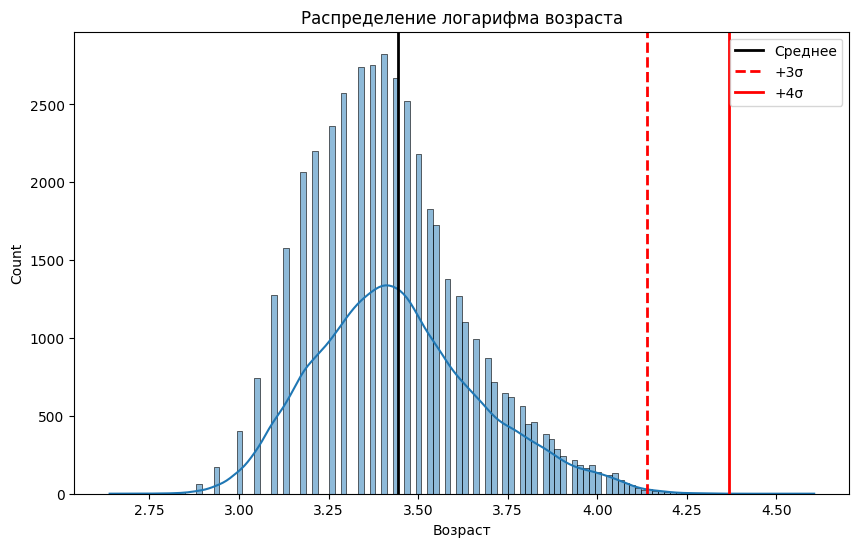

1


In [216]:
log_age = np.log(data['Возраст'])

plt.figure(figsize=(10, 6))
histplot = sns.histplot(log_age, kde=True)
histplot.axvline(log_age.mean(), color='k', lw=2, label='Среднее')
histplot.axvline(log_age.mean() + 3*log_age.std(), color='r', lw=2, linestyle='--', label='+3σ')
histplot.axvline(log_age.mean() + 4*log_age.std(), color='r', lw=2, label='+4σ')
plt.legend()
plt.title('Распределение логарифма возраста')
plt.show()

z_scores = (log_age - log_age.mean()) / log_age.std()
outliers_mask = z_scores > 4
outliers = data[outliers_mask]

print(f"{len(outliers)}")